In [1]:
# Load libraries
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import sys
import datetime

%load_ext autoreload
%autoreload 2

# Import load_csv
from helpers import *
from utils import *
from implementations import *
from preprocess import *

In [2]:
# Dataset shape without using pandas
x_train, x_test, y_train, train_ids, test_ids = load_csv_data('data/dataset')

print("Train set shape : ", x_train.shape)
print("Test set shape : ", x_test.shape)
print("test_ids shape : ", test_ids.shape)
print(test_ids)

Train set shape :  (328135, 321)
Test set shape :  (109379, 321)
test_ids shape :  (109379,)
[328135 328136 328137 ... 437511 437512 437513]


# Data processing

In [3]:
count_rows_with_nan = np.sum(np.isnan(x_train).any(axis=1))
print("Number of rows containing at least one NaN in train set:", count_rows_with_nan)

count_columns_with_nan = np.sum(np.isnan(x_train).any(axis=0))
print("Number of columns containing at least one NaN in train set:", count_columns_with_nan)

count_rows_with_nan = np.sum(np.isnan(x_test).any(axis=1))
print("Number of rows containing at least one NaN in test set:", count_rows_with_nan)

count_columns_with_nan = np.sum(np.isnan(x_test).any(axis=0))
print("Number of columns containing at least one NaN in test set:", count_columns_with_nan)

Number of rows containing at least one NaN in train set: 328135
Number of columns containing at least one NaN in train set: 239
Number of rows containing at least one NaN in test set: 109379
Number of columns containing at least one NaN in test set: 232


All of the lines both in train set and test set contain at least one Nan. 

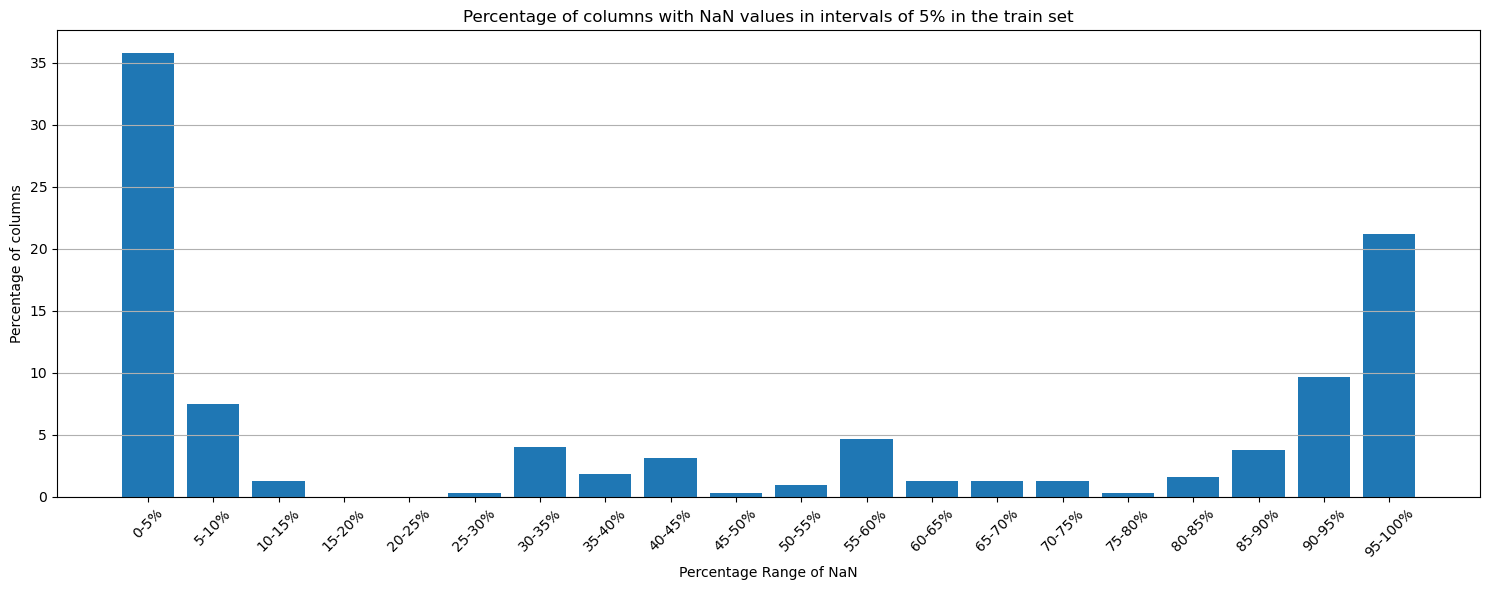

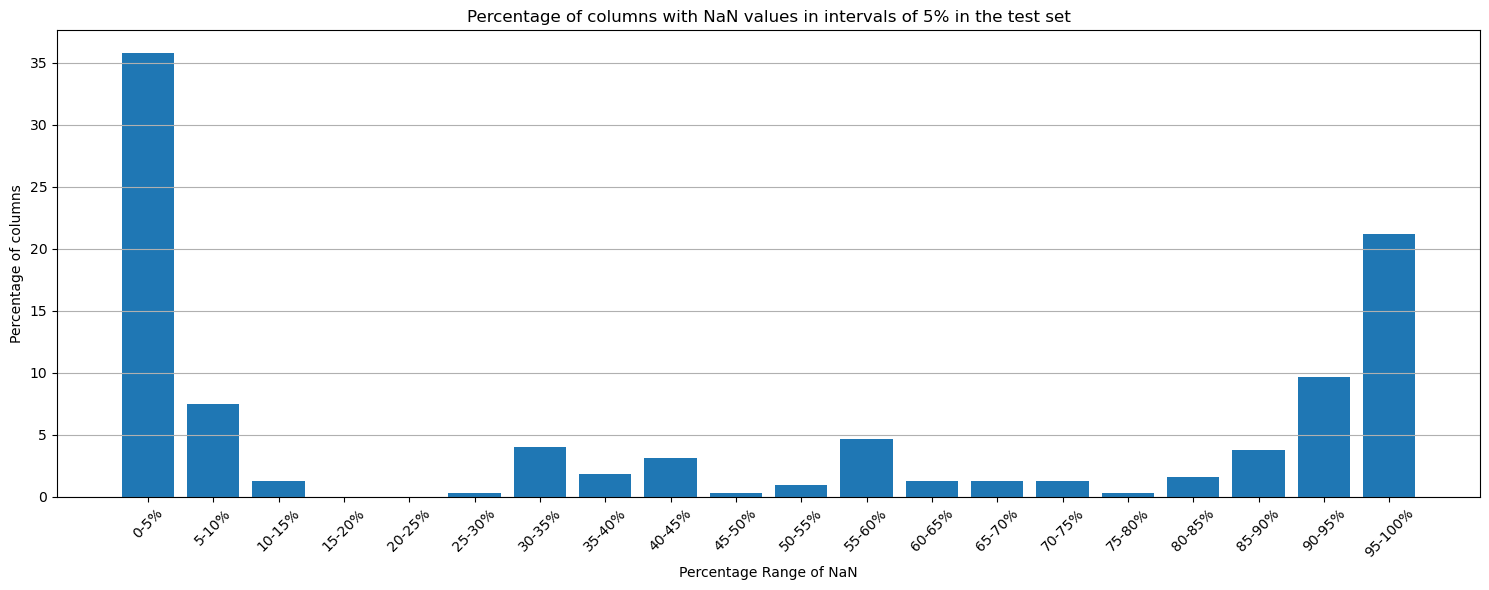

In [4]:
#Analyze the input
show_NaN_cols(x_train, "train set")
show_NaN_cols(x_test, "test set")

### Preprocess data 

In [5]:
# Training set

f_x, cols_excluded = filter_cols(x_train,97)
headers = load_csv_headers("data/dataset/x_train.csv")
features_removed = unused_features_indices(headers)
all_cols_excluded = np.unique(np.concatenate((np.array(features_removed), cols_excluded)))
T_x = np.delete(f_x, all_cols_excluded, axis=1)
T_x = build_log(T_x)
T_x = standardize(T_x)

# Test set


f_x_test, junk = filter_cols(x_test,97)  # junk because we do not need the cols_excluded, since we want to exclude the same columns as in the train set
T_x_test = np.delete(f_x_test, all_cols_excluded, axis=1)
T_x_test = build_log(T_x_test)
T_x_test = standardize(T_x_test)

In [6]:
# export the filtered data to csv
# np.savetxt("data/filtered_dataset.csv", T_x, delimiter=",")

# PCA

In [7]:
covariance_matrix = np.cov(T_x, rowvar=False, dtype=np.float64)

eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

In [8]:
# check if the eingenvalues are complex

if np.any(np.iscomplex(eigenvalues)):
    print("Eigenvalues are complex")
else:
    print("Eigenvalues are real")

Eigenvalues are complex


In [9]:
# Select the number of principal components (e.g., first two)
num_components = 2
selected_eigenvectors = eigenvectors[:, :num_components]
reduced_data = np.dot(T_x, selected_eigenvectors)


c:\Users\rayji\anaconda3\Lib\site-packages\matplotlib\collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


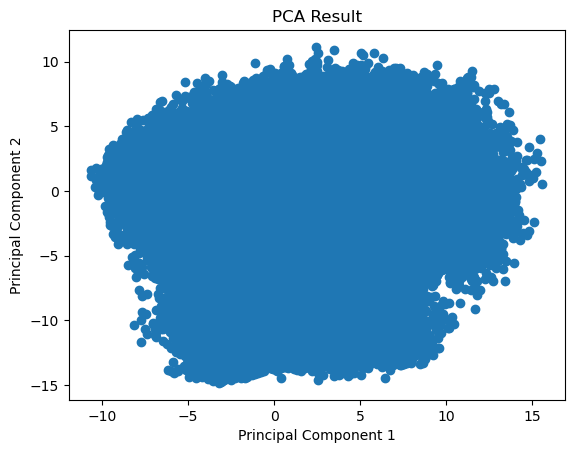

In [10]:
plt.scatter(reduced_data[:, 0], reduced_data[:, 1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result')
plt.show()

c:\Users\rayji\anaconda3\Lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


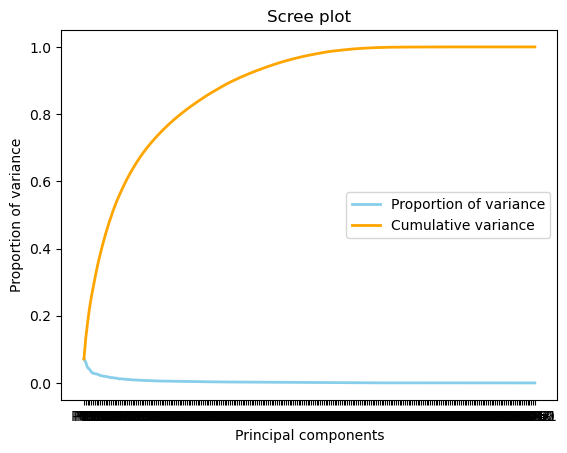

In [11]:
#1. Calculate the proportion of variance explained by each feature
eigenvalues[0] / np.sum(eigenvalues)
sum_eigenvalues = np.sum(eigenvalues)

prop_var = [i/sum_eigenvalues for i in eigenvalues]

#2. Calculate the cumulative variance
cum_var = [np.sum(prop_var[:i+1]) for i in range(len(prop_var))]


#3. Plot the results
x_labels = ['PC{}'.format(i+1) for i in range(len(prop_var))]

plt.plot(x_labels, prop_var, color='skyblue', linewidth=2, label='Proportion of variance')
plt.plot(x_labels, cum_var, color='orange', linewidth=2, label="Cumulative variance")
plt.legend()
plt.title('Scree plot')
plt.xlabel('Principal components')
plt.ylabel('Proportion of variance')
plt.show()

In [12]:
# Number of features we can keep to explain 95% of the variance
num_components = np.where(np.array(cum_var) > 0.95)[0][0] + 1

# Reduce the dimensionality of the data 
selected_eigenvectors = eigenvectors[:, :num_components]
reduced_data = np.dot(T_x, selected_eigenvectors)
print(reduced_data)

[[-1.01135109e+00+0.j  3.58750447e+00+0.j  4.73062358e-02+0.j ...
   4.13270391e-01+0.j -7.60441856e-01+0.j  1.31371068e-01+0.j]
 [ 2.17703778e-01+0.j -9.30353875e+00+0.j  1.37767482e+00+0.j ...
   2.13008804e-01+0.j  5.06273318e-01+0.j -1.48600208e+00+0.j]
 [ 2.07662488e+00+0.j  4.43665398e+00+0.j  3.86562911e+00+0.j ...
  -2.50786762e-01+0.j  3.19282630e-01+0.j  4.13576938e-01+0.j]
 ...
 [ 1.08422972e+00+0.j  5.98573399e-01+0.j  1.24105914e+00+0.j ...
  -1.19640269e-01+0.j  5.61767579e-02+0.j -3.31503654e-01+0.j]
 [-1.40227810e+00+0.j  4.94864100e-03+0.j  7.64931628e-01+0.j ...
   4.72346935e-01+0.j  1.96738931e-01+0.j -2.62023263e-01+0.j]
 [-2.19739128e+00+0.j  3.48352883e+00+0.j  7.95310551e-01+0.j ...
   3.91349451e-01+0.j  5.81972559e-01+0.j  6.61249776e-02+0.j]]


# Predictions

## Without Pre-processing

Dataset Split

In [43]:
# Split the data into train and test sets
x_training_full, x_validation_full, y_training_full, y_validation_full = split_data(f_x, y_train, 0.8)

x_training = x_training_full
x_validation = x_validation_full

# for y keep only labels column for training (drop indexes)
y_training = y_training_full[:, 1]
y_validation = y_validation_full[:, 1]

# Print all shapes

print("x_training shape : ", x_training.shape)
print("x_validation shape : ", x_validation.shape)
print("y_training shape : ", y_training.shape)
print("y_validation shape : ", y_validation.shape)

x_training shape :  (262508, 321)
x_validation shape :  (65627, 321)
y_training shape :  (262508,)
y_validation shape :  (65627,)


### Least Squares

In [14]:
# perform classification using logistic regression

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = least_squares(y_training, x_training)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Least Square: execution time = {t:.3f} seconds".format(t=exection_time))

Least Square: execution time = 0.097 seconds


Training accuracy:  0.6942912216008655
Validation accuracy:  0.6954911850305514
loss :  1.4374946977203727e+28
F1 score:  0.1379518592011043
Precision:  0.09127233289571322


c:\Users\rayji\Documents\GitHub\ml-project-1-stochastik\utils.py:21: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-t))


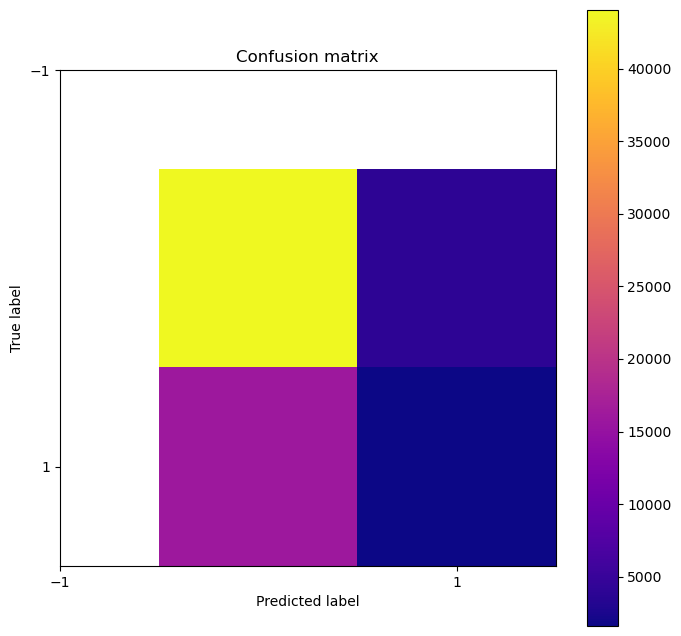

In [15]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

### Gradient Descent

In [16]:
# perform classification using logistic regression

# Define the parameters of the algorithm.
max_iters = 12
gamma = 0.48

# Initialization
w_initial = np.zeros(x_training.shape[1])

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = mean_squared_error_gd(y_training, x_training, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))

Gradient Descent: execution time = 0.347 seconds


c:\Users\rayji\Documents\GitHub\ml-project-1-stochastik\utils.py:38: RuntimeWarning: overflow encountered in square
  return (1 / 2 * np.mean(e**2))


Training accuracy:  0.08880491261218705
Validation accuracy:  0.08629070352141649
loss :  inf
F1 score:  0.15887221209145744
Precision:  0.08629070352141649


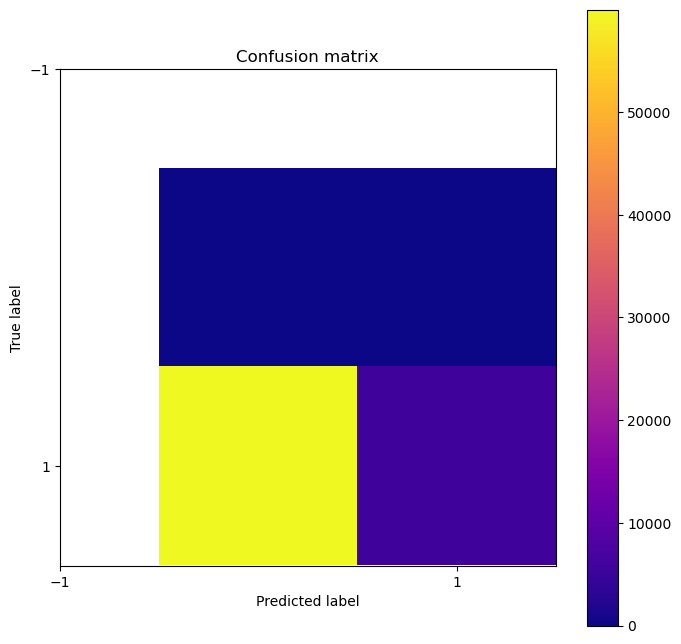

In [17]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

### Stochastic Gradient Descent

In [18]:
# perform classification using logistic regression

# Define the parameters of the algorithm.
max_iters = 12
gamma = 0.48

# Initialization
w_initial = np.zeros(x_training.shape[1])

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = mean_squared_error_sgd(y_training, x_training, w_initial, max_iters, gamma, 5)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Stochastic Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))


Stochastic Gradient Descent: execution time = 2.534 seconds


Training accuracy:  0.08880491261218705
Validation accuracy:  0.08629070352141649
loss :  inf
F1 score:  0.15887221209145744
Precision:  0.08629070352141649


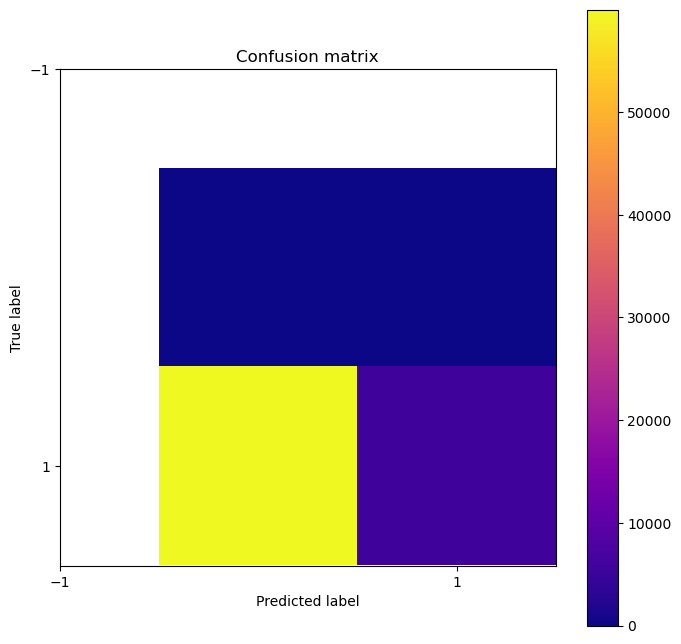

In [19]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

### Ridge Regression

In [20]:
# Define the parameters of the algorithm.
gamma = 0.093

# Start ridge regression.
start_time = datetime.datetime.now()
w, loss = ridge_regression(y_training, x_training, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Ridge Regression: execution time = {t:.3f} seconds".format(t=exection_time))

Ridge Regression: execution time = 0.382 seconds


Training accuracy:  0.4704275679217395
Validation accuracy:  0.46866381215048686
loss :  4.492064793495136e+20
F1 score:  0.1591106395292756
Precision:  0.0921379695573244


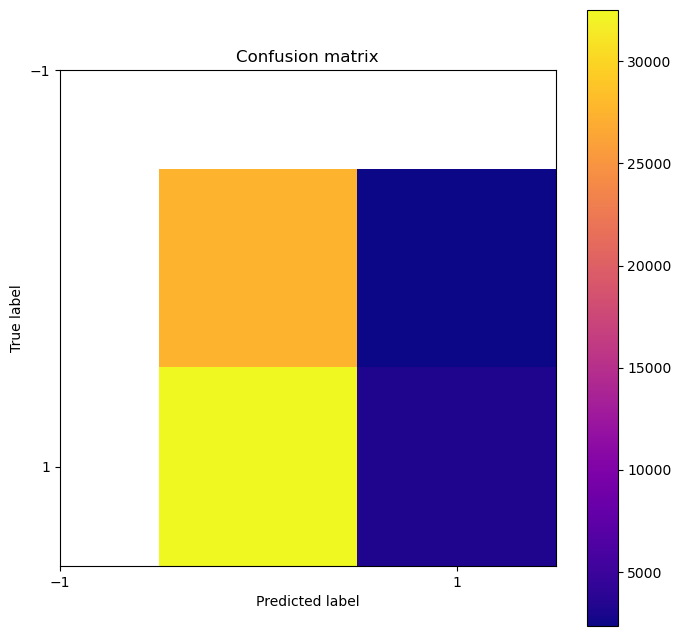

In [21]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

### Logistic Regression

In [46]:
# perform classification using logistic regression

# Define the parameters of the algorithm.
max_iters = 1000
gamma = 1

# Initialization
w_initial = np.zeros(x_training.shape[1])

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = logistic_regression(y_training, x_training, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))

Gradient Descent: execution time = 3.706 seconds


Training accuracy:  0.911195087387813
Validation accuracy:  0.9137092964785835
loss :  nan
F1 score:  0.0
Precision:  nan


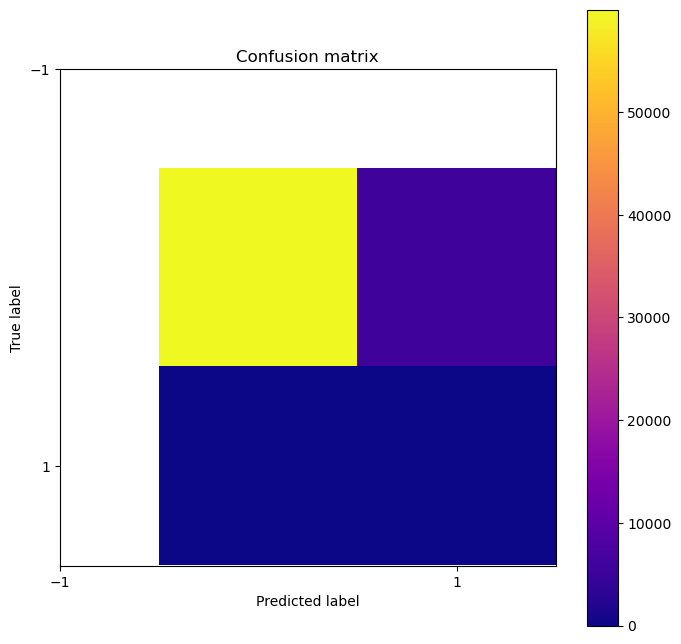

In [47]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

### Regularized Logistic Regression

In [48]:
# Use def reg_logistic_regression(y, tx, lambda_, initial_w, max_iters, gamma):
# to train the model with different lambdas

# Define the parameters of the algorithm.
max_iters = 13
gamma = 0.481
lambda_ = 0

# Initialization
w_initial = np.zeros(x_training.shape[1])

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = reg_logistic_regression_v2(y_training, x_training, lambda_, w_initial, max_iters, gamma, threshold=1e-8)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))


Gradient Descent: execution time = 0.963 seconds


Training accuracy:  0.911195087387813
Validation accuracy:  0.9137092964785835
loss :  nan
F1 score:  0.0
Precision:  nan


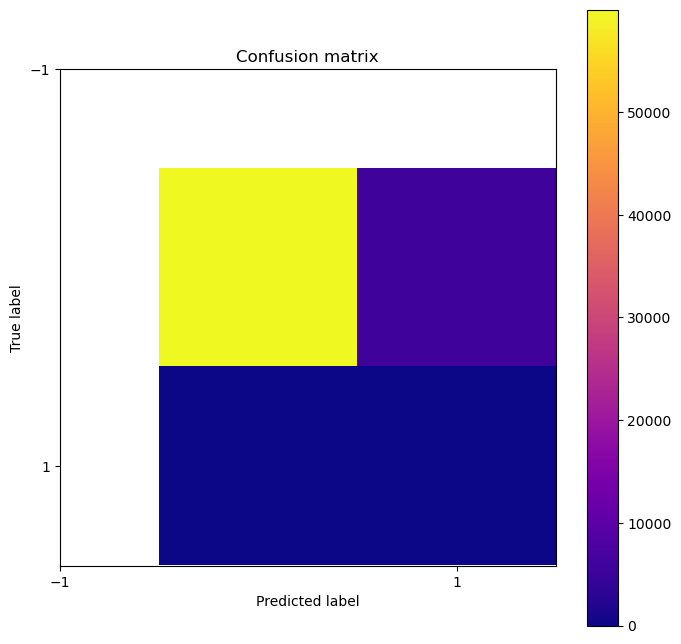

In [49]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

## With Pre-processing

Dataset Split

In [53]:
# Split the data into train and test sets
x_training_full, x_validation_full, y_training_full, y_validation_full = split_data(T_x, y_train, 0.8)

x_training = x_training_full
x_validation = x_validation_full

# for y keep only labels column for training (drop indexes)
y_training = y_training_full[:, 1]
y_validation = y_validation_full[:, 1]

# Print all shapes

print("x_training shape : ", x_training.shape)
print("x_validation shape : ", x_validation.shape)
print("y_training shape : ", y_training.shape)
print("y_validation shape : ", y_validation.shape)

x_training shape :  (262508, 251)
x_validation shape :  (65627, 251)
y_training shape :  (262508,)
y_validation shape :  (65627,)


### Least Squares

In [56]:
# perform classification using logistic regression

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = least_squares(y_training, x_training)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Least Square: execution time = {t:.3f} seconds".format(t=exection_time))

Least Square: execution time = 0.067 seconds


Training accuracy:  0.911195087387813
Validation accuracy:  0.9136940588477304
loss :  0.13350813805459363
F1 score:  0.0
Precision:  0.0


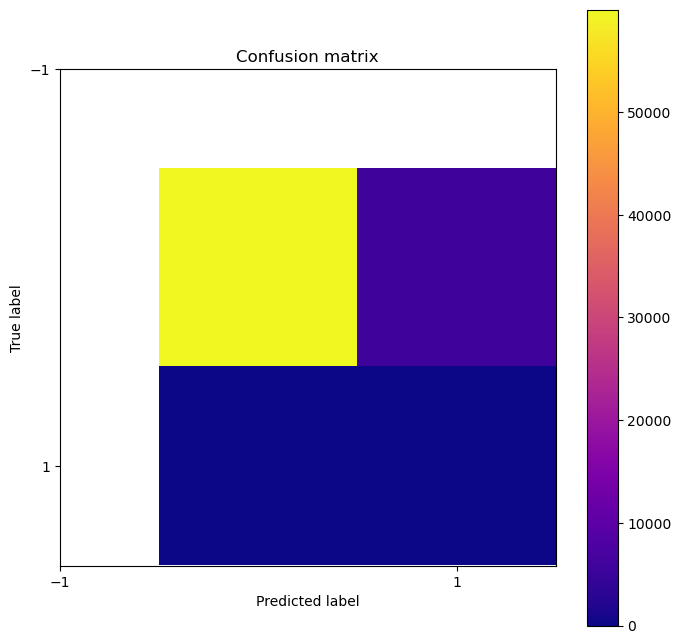

In [57]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

### Gradient Descend

In [29]:
# perform classification using logistic regression

# Define the parameters of the algorithm.
max_iters = 13
gamma = 0.48

# Initialization
w_initial = np.zeros(x_training.shape[1])

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = mean_squared_error_gd(y_training, x_training, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))

Gradient Descent: execution time = 0.307 seconds


Training accuracy:  0.5806146860286163
Validation accuracy:  0.5815746567723651
loss :  1.0659902260559459e+21
F1 score:  0.26659900646332996
Precision:  0.15705340004405424


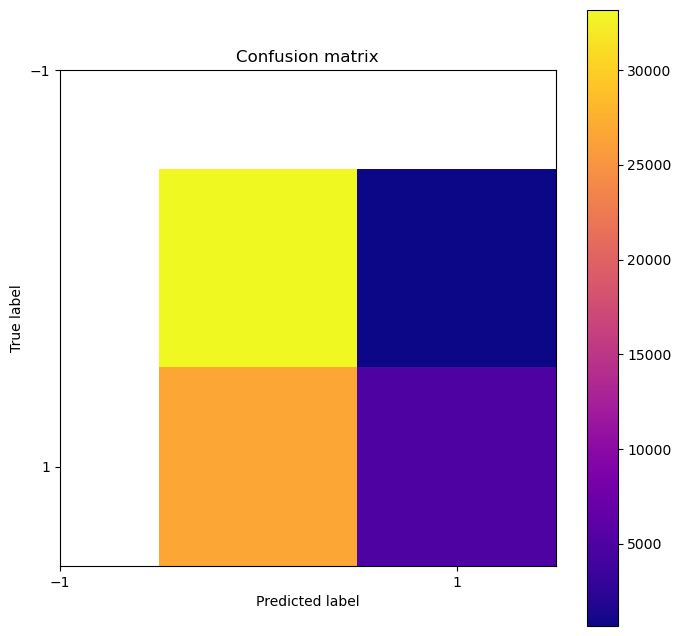

In [30]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

### Stochastic Gradient Descent

In [91]:
# perform classification using logistic regression

# Define the parameters of the algorithm.
max_iters = 12
gamma = 0.48

# Initialization
w_initial = np.zeros(x_training.shape[1])

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = mean_squared_error_sgd(y_training, x_training, w_initial, max_iters, gamma, 5)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Stochastic Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))


Stochastic Gradient Descent: execution time = 1.917 seconds


Training accuracy:  0.5563411400795404
Validation accuracy:  0.55609733798589
loss :  24011.264109509328
F1 score:  0.22677566620660367
Precision:  0.1334457876487677


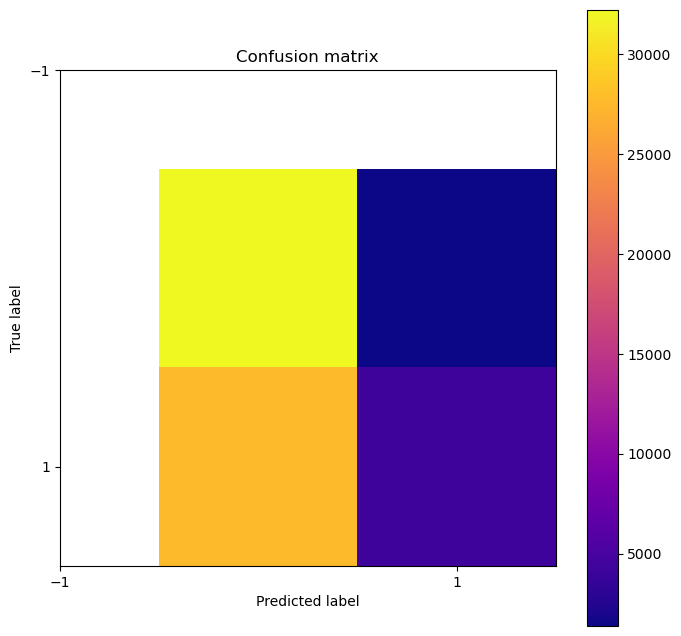

In [92]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

### Ridge Regression

In [107]:
# Define the parameters of the algorithm.
gamma = 0.093

# Start ridge regression.
start_time = datetime.datetime.now()
w, loss = ridge_regression(y_training, x_training, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))

Gradient Descent: execution time = 0.313 seconds


Training accuracy:  0.911195087387813
Validation accuracy:  0.9137245341094367
loss :  0.46979881144950425
F1 score:  0.00035310734463276836
Precision:  1.0


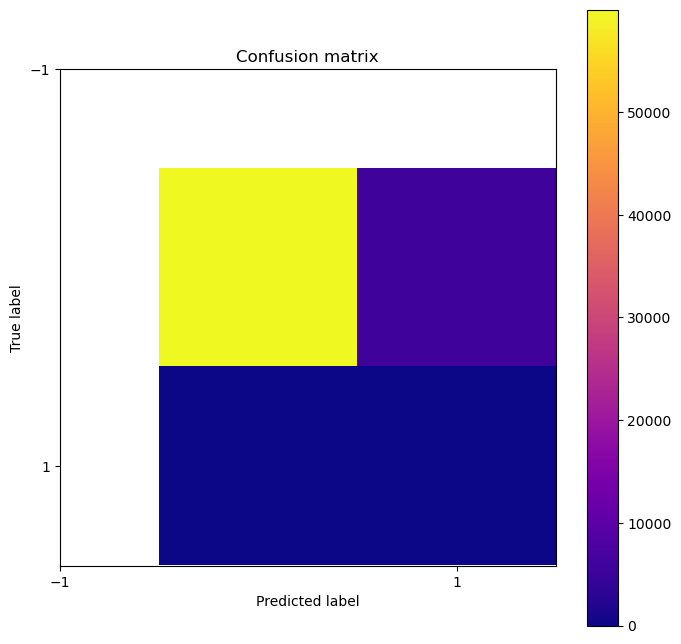

In [108]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

#### Logistic regression

In [115]:
# perform classification using logistic regression

# Define the parameters of the algorithm.
max_iters = 12
gamma = 0.48

# Initialization
w_initial = np.zeros(x_training.shape[1])

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = logistic_regression(y_training, x_training, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))

Gradient Descent: execution time = 0.358 seconds


Training accuracy:  0.8734171910951285
Validation accuracy:  0.8736952778581986
loss :  0.5615786907242815
F1 score:  0.40847784200385356
Precision:  0.34275449101796407


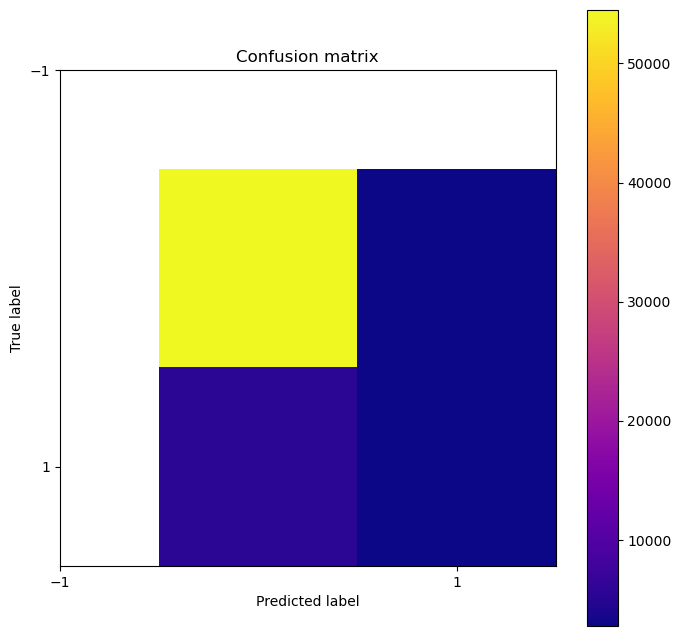

In [114]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

#### Regularized Logistic Regression

In [37]:
# Use def reg_logistic_regression(y, tx, lambda_, initial_w, max_iters, gamma):
# to train the model with different lambdas

# Define the parameters of the algorithm.
max_iters = 13
gamma = 0.481
lambda_ = 0

# Initialization
w_initial = np.zeros(x_training.shape[1])

# Start logistic regression.
start_time = datetime.datetime.now()
w, loss = reg_logistic_regression_v2(y_training, x_training, lambda_, w_initial, max_iters, gamma, threshold=1e-8)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("Gradient Descent: execution time = {t:.3f} seconds".format(t=exection_time))


Gradient Descent: execution time = 0.557 seconds


Training accuracy:  0.8721867524037362
Validation accuracy:  0.8719734255717921
loss :  0.5582300966105613
F1 score:  0.4089758019133371
Precision:  0.33988074359873727


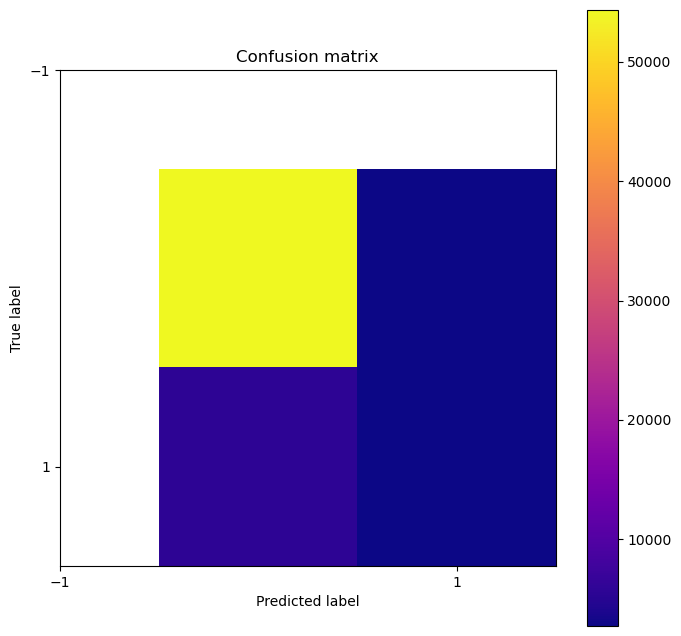

In [38]:
# Calculate the accuracy for the training set and the validation set
y_training_pred = predict(w, x_training)
y_validation_pred = predict(w, x_validation)

training_accuracy = np.sum(y_training_pred == y_training) / len(y_training)
validation_accuracy = np.sum(y_validation_pred == y_validation) / len(y_validation)

print("Training accuracy: ", training_accuracy)
print("Validation accuracy: ", validation_accuracy)

print("loss : ", loss)

plot_results(y_validation_pred, y_validation)

## Grid Search

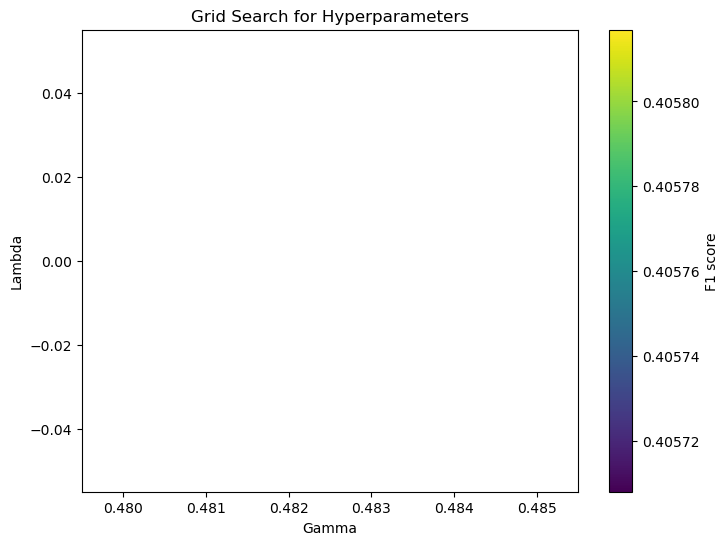

In [39]:
lambda_values = [0]
gamma_values = np.arange(0.48, 0.485, 0.001)

best_lambda, best_gamma, best_f1score = grid_search(lambda_values, gamma_values, y_training, x_training, y_validation, x_validation, max_iters=100)

In [40]:
print("best_lambda : ", best_lambda)
print("best_gamma : ", best_gamma)
print("best_f1score : ", best_f1score)

best_lambda :  0
best_gamma :  0.483
best_f1score :  0.40581689083088684


## Cross Validation

In [41]:
w, loss = cross_validation(x_training, y_training, 5, 0.483)

## K-nearest Neighbor

In [42]:
# Create a k-NN classifier with k=2
knn = KNN(k=2)

# replace the labels that have -1 by 0
y_y_training = y_training.copy()
y_y_training[np.where(y_y_training == -1)] = 0

y_y_validation = y_validation.copy()
y_y_validation[np.where(y_y_validation == -1)] = 0

knn.fit(x_training, y_y_training)

# Make predictions on the test data
predictions = knn.predict(x_validation)
score(predictions, y_y_validation)

KeyboardInterrupt: 

## Submission

Dummy dataset

In [ ]:
# Check what are the values of y_train
print("y_train values : ", np.unique(y_train[:, 1]))

# Check y train shape
print("y_train shape : ", y_train[:, 1].shape)

# Get proportion of -1 and 1 in y_train
proportion_of_0 = np.sum(y_train[:, 1] == -1) / y_train[:, 1].shape[0]
print("Proportion of 0 in y_train : ", proportion_of_0)

# Shape of test set
print("Shape of test set : ", x_test.shape)
 
# Create an array of size 109379 that contain a proportion of 0 and 1 equal to the proportion of 0 and 1 in y_train
y_pred = np.random.choice([-1, 1], size=x_test.shape[0], p=[proportion_of_0, 1-proportion_of_0])

# Get proportion of -1 and 1 in y_test
proportion_of_0 = np.sum(y_pred == -1) / y_pred.shape[0]
print("Proportion of 0 in y_train : ", proportion_of_0)
print("y_test shape : ", y_pred.shape)

y_train values :  [-1  1]
y_train shape :  (328135,)
Proportion of 0 in y_train :  0.911697929205967
Shape of test set :  (109379, 321)
Proportion of 0 in y_train :  0.9115369495058466
y_test shape :  (109379,)


In [ ]:
# Create a csv file with the predictions with best params
w_initial = np.zeros(x_training.shape[1])
w, loss = logistic_regression(y_training, x_training, w_initial, 13, 0.48)
aicrowd_submission(predict(w, T_x_test), "data/dataset/")